# RAINFALL NOWCASTING
Rainfall nowcasting focuses on predicting rainfall over a short future time horizon using recent observations. In this study, we use 30-minute IMERG rainfall data for Chennai from 2021–2025 to investigate how different forecasting approaches perform for short-term rainfall prediction.

We use the 2021–2023 period for training, 2024 for validation, and the unseen 2025 period for final testing. Multiple approaches will be compared, including a persistence baseline, classical time-series forecasting, and deep-learning models, with performance evaluated overall and across Chennai's seasonal rainfall regimes.

## Beginning

### Installings

### Importing

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Dataset loading
We will be using dataset from my google drive directly...

In [ ]:
from google.colab import drive
import os
import shutil

# Attempt to unmount first to ensure a clean state
try:
    drive.flush_and_unmount()
    print("Drive unmounted successfully.")
except Exception as e:
    print(f"Drive was not mounted or unmount failed (expected if not previously mounted): {e}")

# Check if /content/drive exists, is not a mount point, and contains files
# If so, attempt to clear it before mounting
if os.path.isdir('/content/drive') and not os.path.ismount('/content/drive') and os.listdir('/content/drive'):
    print("Mount point directory /content/drive is not empty and not a mount; attempting to clear it.")
    try:
        shutil.rmtree('/content/drive') # Remove directory and its contents
        os.makedirs('/content/drive') # Recreate empty directory
        print("Successfully cleared /content/drive contents.")
    except Exception as e:
        print(f"Failed to clear /content/drive: {e}. This might require a manual runtime restart.")

drive.mount('/content/drive', force_remount=True)

Drive unmounted successfully.
Mounted at /content/drive


In [ ]:
# Check IMERG Folder
import os

print(os.listdir("/content/drive/MyDrive/IMERG"))

['chennai_imerg_30min_2021_2025.csv']


In [ ]:
# Load csv
file_path = "/content/drive/MyDrive/IMERG/chennai_imerg_30min_2021_2025.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print(df.head())

Shape: (87648, 2)
             timestamp  rainfall_mm_hr
0  2021-01-01 00:00:00           0.201
1  2021-01-01 00:30:00           0.000
2  2021-01-01 01:00:00           0.000
3  2021-01-01 01:30:00           0.000
4  2021-01-01 02:00:00           0.000


## Data Preprocessing

### Sorting time stamps
We don't know if the dataset have the timestamps and observations in chronological order, so rather than checking if they are, we force them to get into it...

In [ ]:
# Convert/Sort timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

print(df.dtypes)
print(df.head())

timestamp         datetime64[ns]
rainfall_mm_hr           float64
dtype: object
            timestamp  rainfall_mm_hr
0 2021-01-01 00:00:00           0.201
1 2021-01-01 00:30:00           0.000
2 2021-01-01 01:00:00           0.000
3 2021-01-01 01:30:00           0.000
4 2021-01-01 02:00:00           0.000


### Season detection
We now assign each observation to its corresponding rainfall season so that model performance can later be evaluated across different seasonal regimes.

In [ ]:
# Season Assignment
def assign_season(month):

    if month in [1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Pre-Monsoon"

    elif month in [6, 7, 8, 9]:
        return "Southwest Monsoon"

    else:
        return "Northeast Monsoon"


df["season"] = df["timestamp"].dt.month.apply(assign_season)

print(df[["timestamp", "season"]].head(20))

             timestamp  season
0  2021-01-01 00:00:00  Winter
1  2021-01-01 00:30:00  Winter
2  2021-01-01 01:00:00  Winter
3  2021-01-01 01:30:00  Winter
4  2021-01-01 02:00:00  Winter
5  2021-01-01 02:30:00  Winter
6  2021-01-01 03:00:00  Winter
7  2021-01-01 03:30:00  Winter
8  2021-01-01 04:00:00  Winter
9  2021-01-01 04:30:00  Winter
10 2021-01-01 05:00:00  Winter
11 2021-01-01 05:30:00  Winter
12 2021-01-01 06:00:00  Winter
13 2021-01-01 06:30:00  Winter
14 2021-01-01 07:00:00  Winter
15 2021-01-01 07:30:00  Winter
16 2021-01-01 08:00:00  Winter
17 2021-01-01 08:30:00  Winter
18 2021-01-01 09:00:00  Winter
19 2021-01-01 09:30:00  Winter


### Create season_year column
We now need one more column that would have the value of season and year together. Please ignore the name, the column have the values in format year_season

In [ ]:
# Create season_year
df["year"] = df["timestamp"].dt.year

df["season_year"] = (
    df["year"].astype(str) + "_" +
    df["season"].str.replace(" ", "_").str.replace("-", "")
)

print(df[["timestamp", "season", "season_year"]].head(20))

             timestamp  season  season_year
0  2021-01-01 00:00:00  Winter  2021_Winter
1  2021-01-01 00:30:00  Winter  2021_Winter
2  2021-01-01 01:00:00  Winter  2021_Winter
3  2021-01-01 01:30:00  Winter  2021_Winter
4  2021-01-01 02:00:00  Winter  2021_Winter
5  2021-01-01 02:30:00  Winter  2021_Winter
6  2021-01-01 03:00:00  Winter  2021_Winter
7  2021-01-01 03:30:00  Winter  2021_Winter
8  2021-01-01 04:00:00  Winter  2021_Winter
9  2021-01-01 04:30:00  Winter  2021_Winter
10 2021-01-01 05:00:00  Winter  2021_Winter
11 2021-01-01 05:30:00  Winter  2021_Winter
12 2021-01-01 06:00:00  Winter  2021_Winter
13 2021-01-01 06:30:00  Winter  2021_Winter
14 2021-01-01 07:00:00  Winter  2021_Winter
15 2021-01-01 07:30:00  Winter  2021_Winter
16 2021-01-01 08:00:00  Winter  2021_Winter
17 2021-01-01 08:30:00  Winter  2021_Winter
18 2021-01-01 09:00:00  Winter  2021_Winter
19 2021-01-01 09:30:00  Winter  2021_Winter


### Season summary
We need to check how many rainfall observations we have in each season, but as a summary

In [ ]:
# Summary of data in each season by year

season_counts = (
    df.groupby(["year", "season"])
      .size()
      .unstack(fill_value=0)
)

print(season_counts)

season  Northeast Monsoon  Pre-Monsoon  Southwest Monsoon  Winter
year                                                             
2021                 4416         4416               5856    2832
2022                 4416         4416               5856    2832
2023                 4416         4416               5856    2832
2024                 4416         4416               5856    2880
2025                 4416         4416               5856    2832


### Continuity check
Now we need to check if the data is continuous and persistent over the entire time period so that we can train the models more efficiently.

In [ ]:
# Continuity check
expected_diff = pd.Timedelta(minutes=30)

time_diff = df["timestamp"].diff().dropna()

missing_intervals = (time_diff != expected_diff).sum()

print("Total observations:", len(df))
print("Expected interval: 30 minutes")
print("Non-30-minute intervals:", missing_intervals)

if missing_intervals == 0:
    print("✓ Dataset is completely continuous.")
else:
    print("⚠️ Time gaps detected.")
    print(df.loc[time_diff[time_diff != expected_diff].index])

Total observations: 87648
Expected interval: 30 minutes
Non-30-minute intervals: 0
✓ Dataset is completely continuous.


### Splitting
Here we are splitting the data as 60% for training, 20% for validation, and 20% for testing. This way we will get all four seasons' data in each of the sets.

In [ ]:
# Chronological year-based split: 60/20/20

df["split"] = "test"

# 2021–2023 → Training
df.loc[df["year"].isin([2021, 2022, 2023]), "split"] = "train"

# 2024 → Validation
df.loc[df["year"] == 2024, "split"] = "validation"

# 2025 → Test
df.loc[df["year"] == 2025, "split"] = "test"


# Check the split
print("Training:", (df["split"] == "train").sum())
print("Validation:", (df["split"] == "validation").sum())
print("Test:", (df["split"] == "test").sum())

print("\nPercentages:")
print((df["split"].value_counts(normalize=True) * 100).round(2))

Training: 52560
Validation: 17568
Test: 17520

Percentages:
split
train         59.97
validation    20.04
test          19.99
Name: proportion, dtype: float64


### Verifying splitting
Once the data is split, we need to verify the dates according to which the data is split.

In [ ]:
# Verify split dates
for split in ["train", "validation", "test"]:
    subset = df[df["split"] == split]

    print(
        f"{split.upper():12} | "
        f"{len(subset):6} observations | "

        f"{subset['timestamp'].min()} → {subset['timestamp'].max()}"
    )

TRAIN        |  52560 observations | 2021-01-01 00:00:00 → 2023-12-31 23:30:00
VALIDATION   |  17568 observations | 2024-01-01 00:00:00 → 2024-12-31 23:30:00
TEST         |  17520 observations | 2025-01-01 00:00:00 → 2025-12-31 23:30:00


### Verifying percentage
With the chronological split established, we now verify that the dataset is distributed as intended.
This confirms that approximately 60% is used for training, 20% for validation, and 20% for final testing.

In [ ]:
# Verify percentage
split_counts = df["split"].value_counts()

split_percentages = (split_counts / len(df) * 100).round(2)

print("Observations:")
print(split_counts)

print("\nPercentages:")
print(split_percentages)

Observations:
split
train         52560
validation    17568
test          17520
Name: count, dtype: int64

Percentages:
split
train         59.97
validation    20.04
test          19.99
Name: count, dtype: float64


### Lookback/Horizon
To make short-term rainfall forecasts, we need to define how much recent history the models should use.
We will use the previous 24 hours (48 observations) to predict rainfall 30 minutes ahead

In [ ]:
# Lookback/Horizon
LOOKBACK = 48       # Previous 24 hours
HORIZON = 1         # Next 30 minutes

print("Lookback:", LOOKBACK, "observations (24 hours)")
print("Prediction horizon:", HORIZON, "observation (30 minutes)")

Lookback: 48 observations (24 hours)
Prediction horizon: 1 observation (30 minutes)


### Sequence creation
The continuous rainfall series now needs to be converted into learning examples.
We will create sequences where 48 past observations become the input and the following observation becomes the prediction target

In [ ]:
# Create boundary-safe sequences

def create_sequences(data, lookback=48, horizon=1):
    rainfall = data["rainfall_mm_hr"].values

    X = []
    y = []

    for i in range(lookback, len(rainfall) - horizon + 1):
        X.append(rainfall[i - lookback:i])
        y.append(rainfall[i + horizon - 1])

    return np.array(X), np.array(y)


# Separate the three splits
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "validation"].copy()
test_df  = df[df["split"] == "test"].copy()


# Create sequences
X_train, y_train = create_sequences(train_df, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_df, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_df, LOOKBACK, HORIZON)


print("Training:")
print("X:", X_train.shape, "y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape, "y:", y_val.shape)

print("\nTest:")
print("X:", X_test.shape, "y:", y_test.shape)

Training:
X: (52512, 48) y: (52512,)

Validation:
X: (17520, 48) y: (17520,)

Test:
X: (17472, 48) y: (17472,)


### Visualizing datasets
Since the evaluation must remain independent of training, we should verify the chronological boundaries visually.
This ensures that 2021–2023, 2024, and 2025 remain strictly separated.

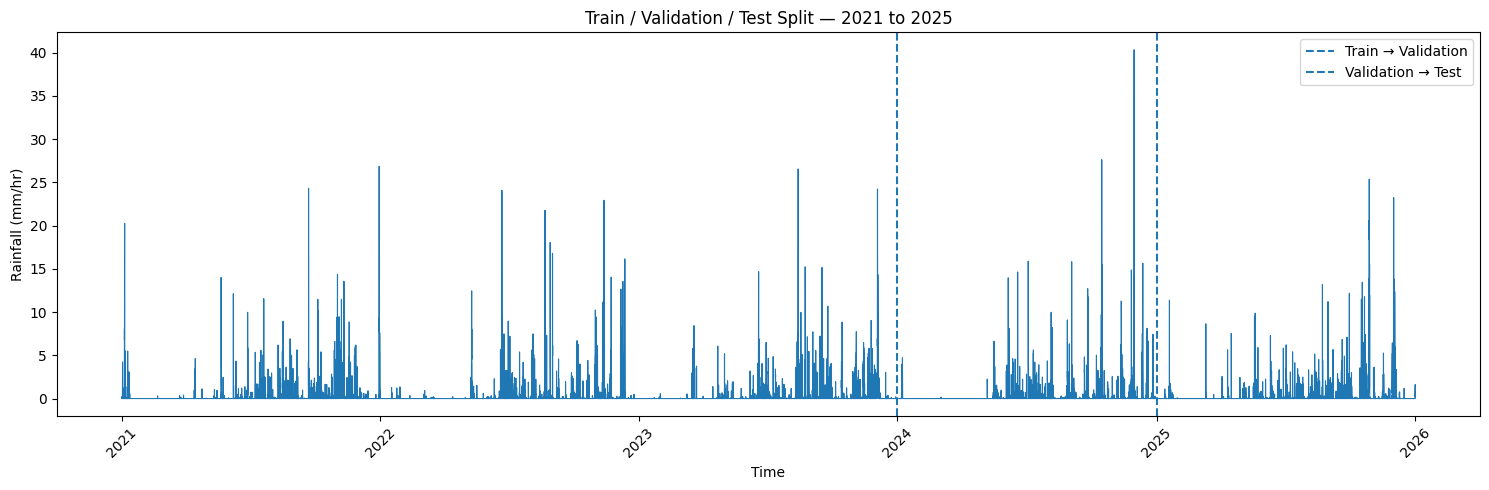

Train ends: 2023-12-31 23:30:00
Validation starts: 2024-01-01 00:00:00

Validation ends: 2024-12-31 23:30:00
Test starts: 2025-01-01 00:00:00


In [ ]:
# Visualize the train/validation/test boundaries

boundary_df = df.copy()

plt.figure(figsize=(15, 5))

plt.plot(
    boundary_df["timestamp"],
    boundary_df["rainfall_mm_hr"],
    linewidth=0.8
)

# Train → Validation
plt.axvline(
    pd.Timestamp("2024-01-01"),
    linestyle="--",
    label="Train → Validation"
)

# Validation → Test
plt.axvline(
    pd.Timestamp("2025-01-01"),
    linestyle="--",
    label="Validation → Test"
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("Train / Validation / Test Split — 2021 to 2025")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("Train ends:", df[df["split"] == "train"]["timestamp"].max())
print("Validation starts:", df[df["split"] == "validation"]["timestamp"].min())

print("\nValidation ends:", df[df["split"] == "validation"]["timestamp"].max())
print("Test starts:", df[df["split"] == "test"]["timestamp"].min())

### Normalization of datasets


The rainfall values span a wide range, so we now need to put them on a suitable numerical scale for neural-network training.
The scaling parameters will be learned only from the training period and then applied to validation and test data.

In [ ]:
# Normalize rainfall using training data only

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit scaler only on training rainfall
scaler.fit(train_df[["rainfall_mm_hr"]].values)

# Transform X
X_train_scaled = scaler.transform(
    X_train.reshape(-1, 1)
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, 1)
).reshape(X_val.shape)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, 1)
).reshape(X_test.shape)

# Transform y
y_train_scaled = scaler.transform(
    y_train.reshape(-1, 1)
).flatten()

y_val_scaled = scaler.transform(
    y_val.reshape(-1, 1)
).flatten()

y_test_scaled = scaler.transform(
    y_test.reshape(-1, 1)
).flatten()


print("Original rainfall range:")
print(
    "Training:",
    train_df["rainfall_mm_hr"].min(),
    "→",
    train_df["rainfall_mm_hr"].max(),
    "mm/hr"
)

print("\nScaled training range:")
print("X_train:", X_train_scaled.min(), "→", X_train_scaled.max())
print("y_train:", y_train_scaled.min(), "→", y_train_scaled.max())

Original rainfall range:
Training: 0.0 → 26.849998474121094 mm/hr

Scaled training range:
X_train: 0.0 → 1.0
y_train: 0.0 → 1.0


## Baseline

Before introducing learned models, we need a simple reference point to determine whether they actually improve the forecast.
We will use persistence, where the next 30-minute rainfall is assumed to equal the most recently observed value.

In [ ]:
# Persistence baseline
# Prediction = most recent observed rainfall

persistence_pred_scaled = X_test_scaled[:, -1]

print("Number of test predictions:", len(persistence_pred_scaled))
print("First 10 predictions:", persistence_pred_scaled[:10])
print("First 10 actual values:", y_test_scaled[:10])

Number of test predictions: 17472
First 10 predictions: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
First 10 actual values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Persistence Evaluation
We now need to measure how well the persistence approach performs on the unseen 2025 test period.
These results will serve as the baseline against which all subsequent models are compared.

In [ ]:
# Evaluate Persistence Baseline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Convert scaled values back to mm/hr
persistence_pred = scaler.inverse_transform(
    persistence_pred_scaled.reshape(-1, 1)
).flatten()

actual_test = scaler.inverse_transform(
    y_test_scaled.reshape(-1, 1)
).flatten()

# Calculate metrics
persistence_mae = mean_absolute_error(
    actual_test,
    persistence_pred
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        persistence_pred
    )
)

persistence_r2 = r2_score(
    actual_test,
    persistence_pred
)

print("Persistence Baseline Results")
print("--------------------------------")
print(f"MAE  : {persistence_mae:.4f} mm/hr")
print(f"RMSE : {persistence_rmse:.4f} mm/hr")
print(f"R²   : {persistence_r2:.4f}")

Persistence Baseline Results
--------------------------------
MAE  : 0.1004 mm/hr
RMSE : 0.5437 mm/hr
R²   : 0.6289


These values are our benchmarks now

# 1. LSTM
`Long Short Term Memory` is a type of recurrent neural network (RNN) that is used to work with sequential data or time-series data.

### Preparing input shape
LSTM expects input as 3 dimensional `(samples, timestamps, feature)`. So we going to convert our `(52512, 48)` to `(52512, 48, 1)`

where `1` means : at each 30-minute timestep, we have one feature - rainfall

In [ ]:
# Prepare data for LSTM

X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_val_lstm = X_val_scaled.reshape(
    X_val_scaled.shape[0],
    X_val_scaled.shape[1],
    1
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

print("Training input shape:", X_train_lstm.shape)
print("Validation input shape:", X_val_lstm.shape)
print("Test input shape:", X_test_lstm.shape)

Training input shape: (52512, 48, 1)
Validation input shape: (17520, 48, 1)
Test input shape: (17472, 48, 1)


### Building LSTM model
Here, we need to build the model, like giving it it's hyperparameters. We are taking 64 hidden units (neurons) in one hidden layer with one hidden layer only. `Dense(1)` means that we want only one neuron at the output.

LSTM and Dense are two layers in Sequential model...

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, LSTM, Dense

# # Build LSTM model
# lstm_model = Sequential([
#     Input(shape=(LOOKBACK, 1)),
#     LSTM(64),
#     Dense(1)
# ])

# lstm_model.summary()

here, trainable params (16,961) mean that model will adjust those many values according to the input and output

### Compiling the model
Before training, the model needs to be told how it should learn and how it should measure its mistakes. For that we'll be using:
1. Adam, which is an optimization algorithm that adjusts the model's parameters.
2. Mean squared error (MSE). It is a loss function that tells the model how wrong its predictions are.

In [ ]:
# # Compile the LSTM model

# lstm_model.compile(
#     optimizer="adam",
#     loss="mse"
# )

# print("LSTM model compiled")

### Training
Now the training process.
But before training there are some things to be learned:
1. `Epochs = 20`: This means the model will go through the entire training dataset 20 times.
2. `Batch size = 64` : This means instead of feeding all 52,512 samples at once, the model processes 64 samples at a time and updates its parameters after each batch.
3. `Validation data` : after each epoch we check the model on the 2024 validation data. This data is not used to update the model's parameters. This is just used to validate the data.


Now, here you change the runtime of colab from cpu to gpu...

In [ ]:
# history = lstm_model.fit(
#     X_train_lstm,
#     y_train_scaled,
#     epochs=20,
#     batch_size=64,
#     validation_data=(X_val_lstm, y_val_scaled),
#     verbose=1
# )

### Plot a graph to visualize the training
We now need to examine how the model learned across the 20 training epochs.
We will compare training loss with validation loss to determine when the model stops improving on unseen validation data.

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))

# plt.plot(history.history["loss"], label="Training Loss")
# plt.plot(history.history["val_loss"], label="Validation Loss")

# plt.xlabel("Epoch")
# plt.ylabel("MSE Loss")
# plt.title("LSTM Training and Validation Loss")
# plt.legend()
# plt.grid(True)

# plt.show()

### Hyperparameter tuning
Now we have the model and it's performance. But the performance is not satisfactory, we need to change it's internal values like no. of epochs, no. of hidden units, etc to see if it performs better with different hyperparameters.

We'll write a function in which we could almost change all the hyperparameter values, that will make not only the function reusable, but also more easier for us to tune.

So we'll be tuning:
1. `Units`: number of LSTM units
2. `Batch_size`: samples processed per batch
3. `Learning_rate`: how aggressively Adam updates parameters
4. `Epochs`: maximum number of passes through the training data
5. `Patience`: how many epochs to wait when validation loss stops improving
6. `Verbose`: how much training output we see

Not only this but we'll also give some default values to our function, which can be forcibly changed when we are calling the function. If we are calling the function directly without any arguments, it still gives a correct baseline configuration.

In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping
# from tensorflow.keras.optimizers import Adam

# def train_lstm(
#     units=64,
#     batch_size=64,
#     learning_rate=0.001,
#     epochs=20,
#     patience=3,
#     verbose=1
# ):
#   model = Sequential([
#       Input(shape=(LOOKBACK, 1)),
#       LSTM(units),
#       Dense(1)
#   ])

#   model.compile(
#       optimizer=Adam(learning_rate=learning_rate),
#       loss="mse"
#   )

#   early_stopping = EarlyStopping(
#       monitor="val_loss",
#       patience=patience,
#       restore_best_weights=True
#   )

#   history = model.fit(
#       X_train_lstm,
#       y_train_scaled,
#       epochs=epochs,
#       batch_size=batch_size,
#       validation_data=(X_val_lstm, y_val_scaled),
#       callbacks=[early_stopping],
#       verbose=verbose
#   )

#   return model, history

In [ ]:
# Now calling the function with different arguments

# model_32, history_32 = train_lstm(units=32)

In [ ]:
# We are taking 64 units again because previously we didn't had the early stopping mechanism.

# model_64, history_64 = train_lstm(units=64)

In [ ]:
# model_80, history_80 = train_lstm(units=80)

In [ ]:
# model_128, history_128 = train_lstm(units=128)

Now we will check what results we get...

In [ ]:
# # Compare LSTM unit configurations

# results = []

# for units, history in [
#     (32, history_32),
#     (64, history_64),
#     (80, history_80),
#     (128, history_128)
# ]:
#     best_epoch = np.argmin(history.history["val_loss"]) + 1
#     best_val_loss = min(history.history["val_loss"])

#     results.append({
#         "Units": units,
#         "Best Epoch": best_epoch,
#         "Best Validation Loss": best_val_loss
#     })

# tuning_results = pd.DataFrame(results)

# print(tuning_results)

We checked for manual hyper parameter tuning, but we cannot test all the possible combinations, so we'll use KerasTuner for it. It is a function that takes input as
```
LSTM units:       32–128
Batch size:       32, 64, 128
Learning rate:    0.0001–0.001
Number of layers: 1–2
```
and then give us a result for which the validation loss is minimum. The function outputs something like
```
Best configuration:
units = 47
layers = 1
batch_size = 32
learning_rate = 0.00037
Best validation loss = ...
```
We will first install dependancies and then write the function.

In [ ]:
!pip install -q keras-tuner

In [ ]:
# import keras_tuner as kt

# def build_lstm_model(hp):

#   model = Sequential([
#       Input(shape=(LOOKBACK, 1)),
#       LSTM(
#           units=hp.Int(
#               "units",
#               min_value=32,
#               max_value=128,
#               step=16
#           )
#       ),
#       Dense(1)
#   ])

#   learning_rate = hp.Choice(
#       "learning_rate",
#       values=[0.001, 0.0005, 0.0001])

#   model.compile(
#       optimizer=Adam(learning_rate=learning_rate),
#       loss="mse"
#   )

#   return model

The above function don't train a model, it just tells keras tuner that
> Add blockquote
here is how to construct a model, and here are he parameters you are allowed to change.


Now we need to check how the model will learn, like who will tell it that which parameters work well and which to try next. Bayesian optimization tells you which value to try next by recording previous trials.

In [ ]:
# tuner = kt.BayesianOptimization(
#     build_lstm_model,
#     objective="val_loss",
#     max_trials=12,
#     directory="/content/drive/MyDrive/keras_tuner",
#     project_name="lstm_rainfall",
#     overwrite=False
# )

In [ ]:
# # Lets see what keras tuner is going to search

# tuner.search_space_summary()

In [ ]:
# # Actual searching/training

# tuner.search(
#     X_train_lstm,
#     y_train_scaled,
#     epochs=20,
#     batch_size=64,
#     validation_data=(X_val_lstm, y_val_scaled),
#     callbacks=[
#         EarlyStopping(
#             monitor="val_loss",
#             patience=3,
#             restore_best_weights=True
#         )
#     ],
#     verbose=1
# )

Now finding for what combination do we get the best value. And save those values

In [ ]:
# best_lstm_model = tuner.get_best_models(num_models=1)[0]

# best_lstm_model.save(
#     "/content/drive/MyDrive/keras_tuner/best_lstm.keras"
# )

In [ ]:
# from tensorflow.keras.models import load_model

# best_lstm_model = load_model(
#     "/content/drive/MyDrive/keras_tuner/best_lstm.keras"
# )

In [ ]:
# best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

# print("Best units:", best_hp.get("units"))
# print("Best learning rate:", best_hp.get("learning_rate"))

In [ ]:
# best_lstm_model = tuner.get_best_models(num_models=1)[0]

In [ ]:
# best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# print("Best validation loss:", best_trial.score)
# print("Best units:", best_hp.get("units"))
# print("Best learning rate:", best_hp.get("learning_rate"))

### Taking the best model in best_lstm_model

In [ ]:
# best_lstm_model = tuner.get_best_models(num_models=1)[0]

# 2. ARIMA

### Checking Stationarity
We need to check if data is stationary, so that it is good for arima - ARIMA works best when series is reasonably stationary.

In [ ]:
train_rainfall = train_df["rainfall_mm_hr"]

print(train_rainfall.describe())

count    52560.000000
mean         0.181427
std          0.958920
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         26.849998
Name: rainfall_mm_hr, dtype: float64


### Augmented Dickey-Fuller (ADF)
This tests whether the series has a statistical pattern that changes over time.
If it is non-stationary, ARIMA's I component can difference the series to make it more stable.
ARIMA(p,d,q)

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_rainfall)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -23.082256152177834
p-value: 0.0


/tmp/ipykernel_813/3074485977.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(train_rainfall)


Null hypothesis: the series is non-stationary.
p-value < 0.05: reject the null hypothesis

The training rainfall series is statistically stationary according to the ADF test.
We conclude ARIMA(p,0,q)

### ACF & PACF
To determine p and q of ARIMA(p,0,q)

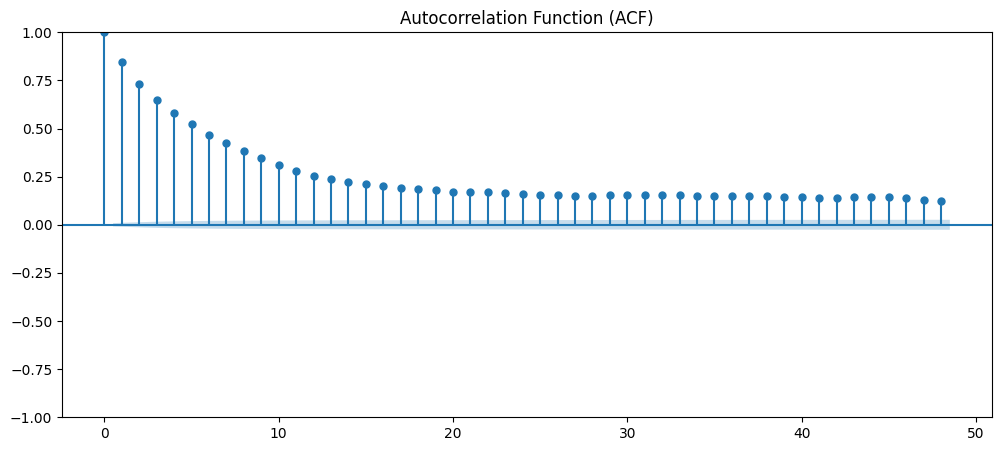

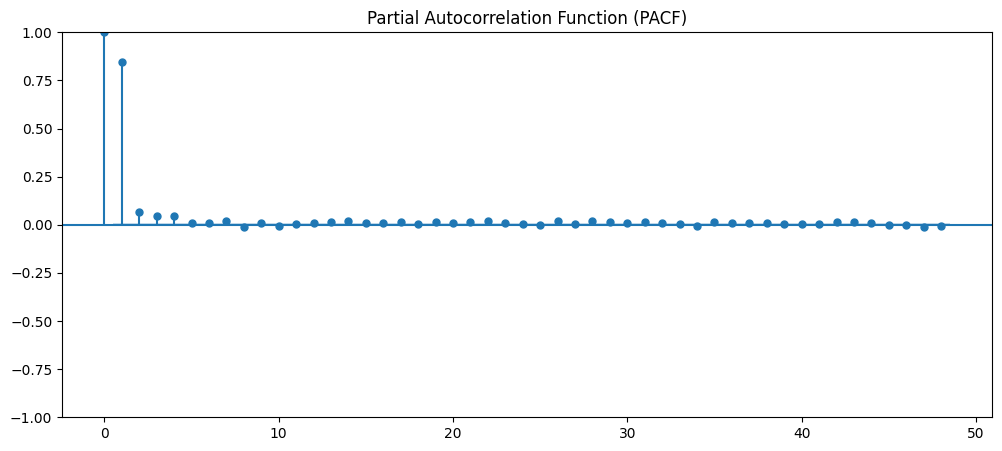

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plot_acf(train_rainfall, lags=48, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(train_rainfall, lags=48, ax=plt.gca(), method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Multitasking function
Writing a function to make the arima model get fitted on various values of p,d,q. First, we'll create the necessary datasets, then write the function.`

In [ ]:
# Function to create datasets for input to function / ARIMA

train_rainfall = train_df["rainfall_mm_hr"].values
val_rainfall = val_df["rainfall_mm_hr"].values

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_arima_rolling(
    order,
    train_data,
    validation_data,
    warmup=48
):
  # Fit ARIMA on training data
  model = ARIMA(train_data, order=order)
  fitted_model = model.fit()

  predictions = []
  actuals = []

  # Walk through the validation data one observation at a time
  for i in range(len(validation_data)):

    # Predict the next 30 minute rainfall
    forecast = fitted_model.forecast(steps=1)[0]

    # Only evaluate after the first 48 validation observations
    if i >= warmup:
      predictions.append(forecast)
      actuals.append(validation_data[i])

    # Give the actual observed value to ARIMA so it can use it for next prediction
    fitted_model = fitted_model.append(
        [validation_data[i]],
        refit=False
    )

  mae = mean_absolute_error(actuals, predictions)
  rmse = np.sqrt(mean_squared_error(actuals, predictions))

  return fitted_model, np.array(predictions), np.array(actuals), mae, rmse

In [ ]:
# arima_test = evaluate_arima_rolling(
#     order=(1,0,0),
#     train_data=train_rainfall,
#     validation_data=val_rainfall[:500],
#     warmup=48
# )

# print(f"MAE: {arima_test[3]:.4f} mm/hr")
# print(f"RMSE: {arima_test[4]:.4f} mm/hr")

### ARIMA Candidate Screening

The ARIMA candidate set is defined using the stationarity and autocorrelation diagnostics performed on the training series. Since the PACF showed strong short-lag dependence and the ADF test supported using no differencing initially, a small set of low-order ARIMA configurations is evaluated.

This screening stage identifies promising configurations efficiently. The best candidates will then undergo full rolling one-step-ahead validation on the complete 2024 validation period.

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd
# import time
# from IPython.display import clear_output

# # Candidate models based on ACF/PACF diagnostics
# arima_candidates = [
#     (1, 0, 0),
#     (2, 0, 0),
#     (3, 0, 0),
#     (1, 0, 1),
#     (2, 0, 1),
#     (1, 0, 2),
#     (2, 0, 2)
# ]

# # Use a manageable validation segment for screening
# SCREEN_SIZE = 500

# val_screen = val_rainfall[:SCREEN_SIZE]

# results = []

# print("ARIMA candidate screening")
# print("=" * 60)

# start_total = time.time()

# for trial, order in enumerate(arima_candidates, start=1):

#     start_model = time.time()

#     try:
#         # Fit only on training data
#         model = ARIMA(train_rainfall, order=order)
#         fitted_model = model.fit()

#         # Forecast the screening period directly
#         predictions = fitted_model.forecast(
#             steps=len(val_screen)
#         )

#         mae = mean_absolute_error(
#             val_screen,
#             predictions
#         )

#         rmse = np.sqrt(
#             mean_squared_error(
#                 val_screen,
#                 predictions
#             )
#         )

#         elapsed_model = time.time() - start_model

#         results.append({
#             "order": order,
#             "MAE": mae,
#             "RMSE": rmse,
#             "time_sec": elapsed_model
#         })

#     except Exception as e:

#         print(f"\nARIMA{order} failed: {e}")

#         results.append({
#             "order": order,
#             "MAE": np.nan,
#             "RMSE": np.nan,
#             "time_sec": np.nan
#         })

#     # Sort completed results by RMSE
#     result_df = (
#         pd.DataFrame(results)
#         .sort_values("RMSE")
#         .reset_index(drop=True)
#     )

#     elapsed_total = time.time() - start_total

#     clear_output(wait=True)

#     print("ARIMA candidate screening")
#     print("=" * 60)
#     print(f"Completed: {trial} / {len(arima_candidates)}")
#     print(f"Current:   ARIMA{order}")
#     print()

#     best = result_df.iloc[0]

#     print("Best so far:")
#     print(f"  ARIMA{best['order']}")
#     print(f"  MAE  = {best['MAE']:.4f} mm/hr")
#     print(f"  RMSE = {best['RMSE']:.4f} mm/hr")
#     print()

#     print(f"Current model time: {elapsed_model:.1f} sec")
#     print(f"Elapsed time:       {elapsed_total/60:.1f} min")
#     print()

#     print("Results so far:")
#     print(
#         result_df.to_string(
#             index=False,
#             formatters={
#                 "MAE": "{:.4f}".format,
#                 "RMSE": "{:.4f}".format,
#                 "time_sec": "{:.1f}".format
#             }
#         )
#     )

# arima_screening_results = result_df

# print("\nScreening complete.")

### ARIMA Validation Screening

The shortlisted ARIMA configurations are evaluated on the 2024 validation period using direct forecasting blocks. This stage is used for computationally efficient model selection after the initial ACF/PACF-based candidate screening.

The final ARIMA forecasting protocol will be fixed before the unseen 2025 test evaluation.

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd
# import time

# # Shortlisted ARIMA configurations
# finalist_orders = [
#     (2, 0, 2),
#     (2, 0, 1),
#     (1, 0, 2)
# ]

# # Evaluate in forecasting blocks
# BLOCK_SIZE = 48   # 24 hours

# results = []

# for order in finalist_orders:

#     print("=" * 60)
#     print(f"Evaluating ARIMA{order}")

#     start_time = time.time()

#     model = ARIMA(
#         train_rainfall,
#         order=order
#     )

#     fitted_model = model.fit()

#     predictions = []
#     actuals = []

#     # Forecast validation data in 24-hour blocks
#     for start in range(0, len(val_rainfall), BLOCK_SIZE):

#         end = min(
#             start + BLOCK_SIZE,
#             len(val_rainfall)
#         )

#         forecast = fitted_model.forecast(
#             steps=end - start
#         )

#         predictions.extend(forecast)
#         actuals.extend(
#             val_rainfall[start:end]
#         )

#     mae = mean_absolute_error(
#         actuals,
#         predictions
#     )

#     rmse = np.sqrt(
#         mean_squared_error(
#             actuals,
#             predictions
#         )
#     )

#     elapsed = time.time() - start_time

#     results.append({
#         "order": order,
#         "MAE": mae,
#         "RMSE": rmse,
#         "time_min": elapsed / 60
#     })

#     print(f"MAE  : {mae:.4f} mm/hr")
#     print(f"RMSE : {rmse:.4f} mm/hr")
#     print(f"Time : {elapsed/60:.2f} min")


# arima_validation_results = (
#     pd.DataFrame(results)
#     .sort_values("RMSE")
#     .reset_index(drop=True)
# )

# print("\nARIMA validation results:")
# display(arima_validation_results)

### ARIMA Residual Diagnostics

Residual diagnostics are performed for the selected ARIMA candidate to determine whether substantial temporal structure remains unexplained after fitting the model.

The diagnostics provide an additional check on model adequacy before the ARIMA configuration is frozen for final testing.

In [ ]:
# from statsmodels.tsa.arima.model import ARIMA
# from statsmodels.graphics.tsaplots import plot_acf
# from statsmodels.stats.diagnostic import acorr_ljungbox
# import matplotlib.pyplot as plt

# # Selected ARIMA candidate
# selected_order = (2, 0, 1)

# # Fit on the complete training data
# arima_model = ARIMA(
#     train_rainfall,
#     order=selected_order
# )

# arima_fitted = arima_model.fit()

# # Extract residuals
# arima_residuals = arima_fitted.resid

# print(f"ARIMA{selected_order} Residual Diagnostics")
# print("=" * 50)

# print(f"Mean residual : {np.mean(arima_residuals):.6f}")
# print(f"Std residual  : {np.std(arima_residuals):.6f}")
# print(f"Residual count: {len(arima_residuals):,}")

# # ACF of residuals
# plt.figure(figsize=(12, 5))

# plot_acf(
#     arima_residuals,
#     lags=48,
#     ax=plt.gca()
# )

# plt.title(f"Residual ACF — ARIMA{selected_order}")
# plt.xlabel("Lag")
# plt.ylabel("Autocorrelation")
# plt.show()

# # Ljung-Box test
# ljung_box = acorr_ljungbox(
#     arima_residuals,
#     lags=[24, 48],
#     return_df=True
# )

# print("\nLjung-Box test:")
# display(ljung_box)

### Save the best arima model
Upto here, we have come to know that arima (2,0,1) performs best, so we'll save it as best model.

In [ ]:
# best_arima_model = ARIMA(
#     train_rainfall,
#     order=(2,0,1)
# ).fit()

In [ ]:
import os
import pickle
from tensorflow.keras.models import load_model

PROJECT_DIR = "/content/drive/MyDrive/SIH_Rainfall_Nowcasting"

LSTM_MODEL_PATH = f"{PROJECT_DIR}/models/LSTM/best_lstm.keras"
ARIMA_MODEL_PATH = f"{PROJECT_DIR}/models/ARIMA/best_arima_2_0_1.pkl"

assert os.path.exists(LSTM_MODEL_PATH), "LSTM model file not found."
assert os.path.exists(ARIMA_MODEL_PATH), "ARIMA model file not found."

best_lstm_model = load_model(LSTM_MODEL_PATH)

with open(ARIMA_MODEL_PATH, "rb") as f:
    best_arima_model = pickle.load(f)

print("Saved LSTM model loaded.")
print("Saved ARIMA model loaded.")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 12 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved LSTM model loaded.
Saved ARIMA model loaded.


# 3. GRU
A Gated Recurrent Unit (GRU) is a recurrent neural network designed to learn temporal dependencies in sequential data.

In this study, the GRU receives the previous 48 half-hour rainfall observations (24 hours) and predicts rainfall for the next 30-minute interval.

### Preparing input shape

GRU expects a 3-dimensional input in the form `(samples, timestamps, features)`.

Our rainfall sequences currently have the shape `(samples, 48)`, so we add one feature dimension to obtain `(samples, 48, 1)`.

Here, `1` represents the single feature available at each timestep: rainfall.

We have already did this in LSTM section, so we'll run the cell again and get the required input format

### Building GRU model
A GRU (Gated Recurrent Unit) is a recurrent neural network designed to model dependencies in sequential data.

The GRU receives the previous 48 rainfall observations and learns how earlier rainfall patterns relate to the rainfall at the next timestep.

We use 64 GRU units and a single output neuron for predicting the next 30-minute rainfall value.

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, GRU, Dense

# # Define the GRU model
# gru_model = Sequential([
#     Input(shape=(LOOKBACK, 1)),
#     GRU(64),
#     Dense(1)
# ])

# gru_model.summary()

### Compiling the model

The GRU is trained using the Adam optimizer and mean squared error (MSE) as the loss function.

MSE penalizes larger prediction errors more strongly, which is appropriate for continuous rainfall-rate prediction.

In [ ]:
# gru_model.compile(
#     optimizer="adam",
#     loss="mse"
# )

### Training

The GRU is initially trained for 20 epochs using a batch size of 64.

The validation set is monitored during training to observe how well the model generalizes to unseen data.

In [ ]:
# history_gru = gru_model.fit(
#     X_train_lstm,
#     y_train_scaled,
#     epochs=20,
#     batch_size=64,
#     validation_data=(X_val_lstm, y_val_scaled),
#     verbose=1
# )

## Hyperparameter tuning
Rather than training on manual values, we will write a function to search best hyper parameters

In [ ]:
# import keras_tuner as kt

# def build_gru_model(hp):

#     model = Sequential([
#         Input(shape=(LOOKBACK, 1)),

#         GRU(
#             units=hp.Int(
#                 "units",
#                 min_value=32,
#                 max_value=128,
#                 step=16
#             )
#         ),

#         Dense(1)
#     ])

#     learning_rate = hp.Choice(
#         "learning_rate",
#         values=[0.001, 0.0005, 0.0001]
#     )

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(
#             learning_rate=learning_rate
#         ),
#         loss="mse"
#     )

#     return model

Setting up hyper parameter tuning

In [ ]:
# import tensorflow as tf
# from tensorflow.keras.callbacks import EarlyStopping

# PROJECT_DIR = "/content/drive/MyDrive/SIH_Rainfall_Nowcasting"

# early_stopping = EarlyStopping(
#     monitor="val_loss",
#     patience=3,
#     restore_best_weights=True
# )

# tuner_gru = kt.BayesianOptimization(
#     build_gru_model,
#     objective="val_loss",
#     max_trials=12,
#     directory=f"{PROJECT_DIR}/keras_tuner",
#     project_name="gru_tuning",
#     overwrite=True
# )

Training and searching for the best hyperparameters

In [ ]:
# tuner_gru.search(
#     X_train_lstm,
#     y_train_scaled,
#     validation_data=(X_val_lstm, y_val_scaled),
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stopping],
#     verbose=1
# )

### Getting the best model

In [ ]:
# best_gru_hp = tuner_gru.get_best_hyperparameters(num_trials=1)[0]

# print("Units:", best_gru_hp.get("units"))
# print("Learning rate:", best_gru_hp.get("learning_rate"))

In [ ]:
# best_gru_model = tuner_gru.get_best_models(num_models=1)[0]

# best_gru_model.summary()

Save the model to drive.

In [ ]:
# GRU_MODEL_DIR = f"{PROJECT_DIR}/models/GRU"
# os.makedirs(GRU_MODEL_DIR, exist_ok=True)

# GRU_MODEL_PATH = f"{GRU_MODEL_DIR}/best_gru.keras"

# best_gru_model.save(GRU_MODEL_PATH)

# print("GRU Model saved to : ", GRU_MODEL_PATH)

# 4. 1D CNN
A one-dimensional convolutional neural network that learns local `temporal patterns` from the rainfall sequence. It uses convolutional `filters` to examine consecutive time steps and extract short-term features, which are then used to predict the next rainfall value.

`temporal patterns:` Patterns that change with time.

### Buildingg 1D CNN model

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense

# cnn_model = Sequential([
#     Input(shape=(LOOKBACK, 1)),
#     Conv1D(filters=64, kernel_size=3, activation="relu"),
#     GlobalAveragePooling1D(),
#     Dense(1)
# ])

# cnn_model.summary()

### Hyperparameter tuning
Here we'll define for filters from 32 to 128, kernel size for 3,5,7, and learning rate same as gru.
This will give 36 combinations.

`filters:`The number of different convolutional filters used by the CNN. Each filter learns different local temporal features from the rainfall sequence.

Temporal feature : feature changing with time

`kernel:`The number of consecutive time steps examined by each filter at a time. It determines the temporal width of the local pattern the CNN can learn.
kernel size 3 => it will look at 3 values and try to find relation between them

In [ ]:
# # Function to build models as per requirements

# import keras_tuner as kt
# import tensorflow as tf

# def build_cnn_model(hp):

#   model = Sequential([
#       Input(shape=(LOOKBACK, 1)),

#       Conv1D(
#           filters=hp.Int(
#               "filters",
#               min_value=32,
#               max_value=128,
#               step=32
#           ),
#           kernel_size=hp.Choice(
#               "kernel",
#               values=[3, 5, 7]
#           ),
#           activation="relu"
#       ),
#       GlobalAveragePooling1D(),
#       Dense(1)
#   ])

#   learning_rate = hp.Choice(
#       "learning_rate",
#       values=[0.001, 0.0005, 0.0001]
#   )

#   model.compile(
#       optimizer=tf.keras.optimizers.Adam(
#           learning_rate=learning_rate
#       ),
#       loss="mse"
#   )

#   return model

In [ ]:
# # Early stopping function

# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor="val_loss",
#     patience=3,
#     restore_best_weights=True
# )

In [ ]:
# # CNN tuner
# import keras_tuner as kt

# tuner_cnn = kt.BayesianOptimization(
#     build_cnn_model,
#     objective="val_loss",
#     max_trials=12,
#     directory=f"{PROJECT_DIR}/keras_tuner",
#     project_name="cnn_tuning_v2",
#     overwrite=True
# )

In [ ]:
# # Search for best hp

# tuner_cnn.search(
#     X_train_lstm,
#     y_train_scaled,
#     validation_data=(X_val_lstm, y_val_scaled),
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stopping],
#     verbose=1)

### Get the best hyperparameters
Now we get best model

In [ ]:
# best_cnn_hp = tuner_cnn.get_best_hyperparameters(num_trials=1)[0]

# print("Best CNN hyperparameters:")
# print("Filters       :", best_cnn_hp.get("filters"))
# print("Kernel size   :", best_cnn_hp.get("kernel"))
# print("Learning rate :", best_cnn_hp.get("learning_rate"))

The model uses 64 filters with a kernel size of 3, meaning each filter examines 3 consecutive 30-minute rainfall observations at a time

Saving the best model in drive

In [ ]:
# best_cnn_model = tuner_cnn.get_best_models(num_models=1)[0]

# print("Best model retrieved.")

In [ ]:
# CNN_MODEL_DIR = f"{PROJECT_DIR}/models/CNN"
# os.makedirs(CNN_MODEL_DIR, exist_ok=True)

# CNN_MODEL_PATH = f"{CNN_MODEL_DIR}/best_cnn.keras"

# best_cnn_model.save(CNN_MODEL_PATH)

# print("CNN Model saved to : ", CNN_MODEL_PATH)

# 5. CNN-LSTM
A hybrid neural network that combines a 1D CNN and an LSTM. The CNN first extracts local temporal patterns from the rainfall sequence, and the LSTM then learns how these extracted patterns change over time to predict the next rainfall value.

`1D CNN:` Extracts local temporal patterns.

`LSTM:` Learns temporal dependancies directly from sequences.

`CNN-LSTM:` CNN extracts patterns → LSTM learns their temporal dependencies.

### Checking dataset
CNN LSTM expects three inputs like for our lstm and gru models.

In [ ]:
# print("Training input shape   :", X_train_lstm.shape)
# print("Validation input shape :", X_val_lstm.shape)
# print("Test input shape       :", X_test_lstm.shape)

### Build CNN LSTM architecture
Now we need to build the architecture for cnn lstm as we did earlier for previous models

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense

# cnn_lstm_model = Sequential([
#     Input(shape=(LOOKBACK, 1)),

#     Conv1D(
#         filters=64,
#         kernel_size=3,
#         activation="relu"
#     ),

#     LSTM(64),

#     Dense(1)
# ])

# cnn_lstm_model.summary()

compile the model

In [ ]:
# cnn_lstm_model.compile(
#     optimizer="adam",
#     loss="mse"
# )

### Finding hyperparameters
CNN filters: `32–128`

CNN kernel `size: 3, 5, 7`

LSTM units: `32–128`

Learning rate: `0.001, 0.0005, 0.0001`

In [ ]:
# def build_cnn_lstm_model(hp):

#   model = Sequential([
#       Input(shape=(LOOKBACK, 1)),

#       Conv1D(
#           filters=hp.Int(
#               "filters",
#               min_value=32,
#               max_value=128,
#               step=32
#           ),
#           kernel_size=hp.Choice(
#               "kernel",
#               values=[3, 5, 7]
#           ),
#           activation="relu"
#       ),

#       LSTM(
#           units=hp.Int(
#               "lstm_units",
#               min_value=32,
#               max_value=128,
#               step=16
#           )
#       ),

#       Dense(1)
#   ])

#   learning_rate = hp.Choice(
#       "learning_rate",
#       values=[0.001, 0.0005, 0.0001]
#   )

#   model.compile(
#       optimizer=tf.keras.optimizers.Adam(
#           learning_rate=learning_rate
#       ),
#       loss="mse"
#   )

#   return model

### Creating tuner

In [ ]:
# tuner_cnn_lstm = kt.BayesianOptimization(
#     build_cnn_lstm_model,
#     objective="val_loss",
#     max_trials=12,
#     directory=f"{PROJECT_DIR}/keras_tuner",
#     project_name="cnn_lstm_tuning",
#     overwrite=True
# )

### Search
Now running the search

In [ ]:
# tuner_cnn_lstm.search(
#     X_train_lstm,
#     y_train_scaled,
#     validation_data=(X_val_lstm, y_val_scaled),
#     epochs=50,
#     batch_size=64,
#     callbacks=[early_stopping],
#     verbose=1
# )

In [ ]:
# # getting config of best cnn lstm

# best_cnn_lstm_hp = tuner_cnn_lstm.get_best_hyperparameters(num_trials=1)[0]

# print("Best CNN-LSTM hyperparameters:")
# print("Filters       :", best_cnn_lstm_hp.get("filters"))
# print("Kernel size   :", best_cnn_lstm_hp.get("kernel"))
# print("LSTM units    :", best_cnn_lstm_hp.get("lstm_units"))
# print("Learning rate :", best_cnn_lstm_hp.get("learning_rate"))

Getting the best cnn lstm model

In [ ]:
# best_cnn_lstm_model = tuner_cnn_lstm.get_best_models(num_models=1)[0]

# print("Best CNN LSTM Model retrieved")

add it to drive

In [ ]:
# CNN_LSTM_MODEL_DIR = f"{PROJECT_DIR}/models/CNN_LSTM"
# os.makedirs(CNN_LSTM_MODEL_DIR, exist_ok=True)

# CNN_LSTM_MODEL_PATH = f"{CNN_LSTM_MODEL_DIR}/best_cnn_lstm.keras"

# best_cnn_lstm_model.save(CNN_LSTM_MODEL_PATH)

# print("CNN LSTM Model saved to : ", CNN_LSTM_MODEL_PATH)

# Done with Model training

### Let's try fetching
Now we will check if we are able to load all the models successfully.

In [ ]:
import os
import pickle
from tensorflow.keras.models import load_model

# Model paths
LSTM_MODEL_PATH = f"{PROJECT_DIR}/models/LSTM/best_lstm.keras"
GRU_MODEL_PATH = f"{PROJECT_DIR}/models/GRU/best_gru.keras"
CNN_MODEL_PATH = f"{PROJECT_DIR}/models/CNN/best_cnn.keras"
CNN_LSTM_MODEL_PATH = f"{PROJECT_DIR}/models/CNN_LSTM/best_cnn_lstm.keras"
ARIMA_MODEL_PATH = f"{PROJECT_DIR}/models/ARIMA/best_arima_2_0_1.pkl"

# Load neural models
best_lstm_model = load_model(LSTM_MODEL_PATH)
best_gru_model = load_model(GRU_MODEL_PATH)
best_cnn_model = load_model(CNN_MODEL_PATH)
best_cnn_lstm_model = load_model(CNN_LSTM_MODEL_PATH)

# Load ARIMA
with open(ARIMA_MODEL_PATH, "rb") as f:
    best_arima_model = pickle.load(f)

print("All models loaded successfully.")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


All models loaded successfully.


# 6. Evaluation
Now here we start evaluation metrics and the dirty mathematics

### Checking dataset
We'll first check if our test data is good. Maybe it may have affected due to training so many models (which does not sound logical, but still, let's check)

In [ ]:
# Test rainfall values in their original mm/hr scale
test_rainfall = test_df["rainfall_mm_hr"].values

print("Test observations:", len(test_rainfall))
print("Test period:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())

Test observations: 17520
Test period: 2025-01-01 00:00:00 to 2025-12-31 23:30:00


Okay, the data is good

## 1. ARIMA

### Now get arima rainfall forecasts

In [ ]:
arima_model = best_arima_model

In [ ]:
import numpy as np

arima_forecast = []

for actual_value in test_rainfall:

  # Forecast the next observation
  forecast = arima_model.forecast(steps=1)[0]
  arima_forecast.append(forecast)

  # Update the model with the newly observed value
  arima_model = arima_model.extend([actual_value])

arima_predictions = np.array(arima_forecast)

In [ ]:
print("ARIMA Predictions:", len(arima_predictions))
print("First 10 predictions:", arima_predictions[:10])

ARIMA Predictions: 17520
First 10 predictions: [0.02281257 0.02281257 0.02281257 0.02281257 0.02281257 0.02281257
 0.02281257 0.02281257 0.02281257 0.02281257]


Uh hmm, That looks suspicious, we now need to check if all the values are 0.02281... because, that would mean we didn't train it correctly or the model broke

In [ ]:
print("Prediction statistics:")
print("Min       :", arima_predictions.min())
print("Max       :", arima_predictions.max())
print("Mean      :", arima_predictions.mean())
print("Std       :", arima_predictions.std())

print("\nUnique prediction values:", len(np.unique(arima_predictions)))

print("\nPredictions at selected positions:")
for i in [0, 1, 10, 100, 1000, 5000, 10000, 15000, 17519]:
    print(i, ":", arima_predictions[i])

Prediction statistics:
Min       : 0.022812570265011572
Max       : 21.092644643099412
Mean      : 0.1674224585199753
Std       : 0.7505953905912175

Unique prediction values: 10704

Predictions at selected positions:
0 : 0.022812570265011572
1 : 0.022812570265011572
10 : 0.022812570265011572
100 : 0.022812570265011572
1000 : 0.02281257045693494
5000 : 0.022812570265011572
10000 : 0.0228175000727647
15000 : 0.022813471574733346
17519 : 0.4557095061469739


Okay, the values tell that not all the predicted values are bad, it's just the timesteps we chose to predict, that might have caused the error

Arima is not restricted to positive predictions, it can give -ve predictions also, so we'll check if it has any negative predictions, that would be something suspicious

In [ ]:
negative_count = np.sum(arima_predictions < 0)

print("Negative predictions:", negative_count)
print("Minimum prediction  :", arima_predictions.min())

Negative predictions: 0
Minimum prediction  : 0.022812570265011572


### ARIMA metrics

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

arima_mae = mean_absolute_error(test_rainfall, arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(test_rainfall, arima_predictions))
arima_r2 = r2_score(test_rainfall, arima_predictions)

print("ARIMA — 2025 Test Results")
print("-------------------------")
print("MAE  :", arima_mae)
print("RMSE :", arima_rmse)
print("R²   :", arima_r2)

ARIMA — 2025 Test Results
-------------------------
MAE  : 0.11591766416787025
RMSE : 0.5150405810556992
R²   : 0.6661738501657033


Didn't like the numbers ?

I didn't even get them, I have something better

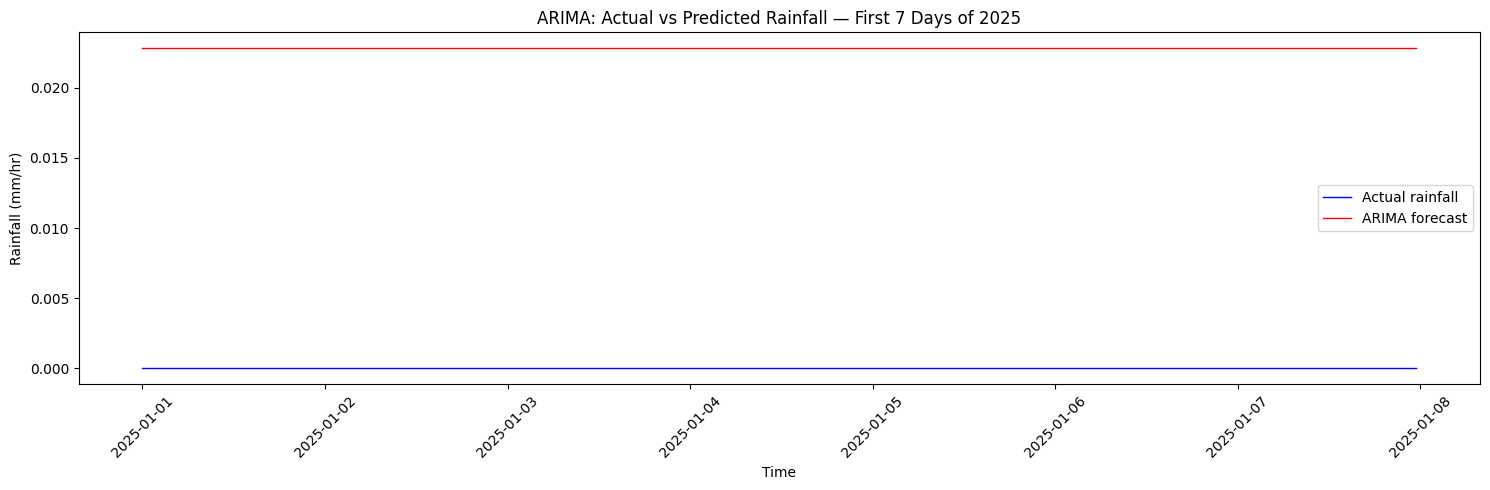

In [ ]:
import matplotlib.pyplot as plt

# Show the first 7 days of the 2025 test period
n_points = 7*48

plt.figure(figsize=(15, 5))

plt.plot(
    test_df["timestamp"].iloc[:n_points],
    test_rainfall[:n_points],
    label="Actual rainfall",
    color="blue",
    linewidth=1
)

plt.plot(
    test_df["timestamp"].iloc[:n_points],
    arima_predictions[:n_points],
    label="ARIMA forecast",
    color="red",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("ARIMA: Actual vs Predicted Rainfall — First 7 Days of 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

uh hmm, the predictions again seem suspicious. Let's test

In [ ]:
# Diagnose ARIMA behavior during the first 7 days of 2025

n_points = 7 * 48

diagnostic_df = pd.DataFrame({
    "timestamp": test_df["timestamp"].iloc[:n_points].values,
    "actual": test_rainfall[:n_points],
    "prediction": arima_predictions[:n_points]
})

print("First 20 predictions:")
print(diagnostic_df.head(20).to_string(index=False))

print("\nUnique predictions in first 7 days:",
      diagnostic_df["prediction"].nunique())

print("\nPrediction range in first 7 days:")
print("Min:", diagnostic_df["prediction"].min())
print("Max:", diagnostic_df["prediction"].max())

print("\nFirst 7 days actual rainfall:")
print("Non-zero observations:",
      (diagnostic_df["actual"] > 0).sum())
print("Maximum:",
      diagnostic_df["actual"].max())

First 20 predictions:
          timestamp  actual  prediction
2025-01-01 00:00:00     0.0    0.022813
2025-01-01 00:30:00     0.0    0.022813
2025-01-01 01:00:00     0.0    0.022813
2025-01-01 01:30:00     0.0    0.022813
2025-01-01 02:00:00     0.0    0.022813
2025-01-01 02:30:00     0.0    0.022813
2025-01-01 03:00:00     0.0    0.022813
2025-01-01 03:30:00     0.0    0.022813
2025-01-01 04:00:00     0.0    0.022813
2025-01-01 04:30:00     0.0    0.022813
2025-01-01 05:00:00     0.0    0.022813
2025-01-01 05:30:00     0.0    0.022813
2025-01-01 06:00:00     0.0    0.022813
2025-01-01 06:30:00     0.0    0.022813
2025-01-01 07:00:00     0.0    0.022813
2025-01-01 07:30:00     0.0    0.022813
2025-01-01 08:00:00     0.0    0.022813
2025-01-01 08:30:00     0.0    0.022813
2025-01-01 09:00:00     0.0    0.022813
2025-01-01 09:30:00     0.0    0.022813

Unique predictions in first 7 days: 1

Prediction range in first 7 days:
Min: 0.022812570265011572
Max: 0.022812570265011572

First 7 day

### Whole year performance
Let's see how did it perform all over the years

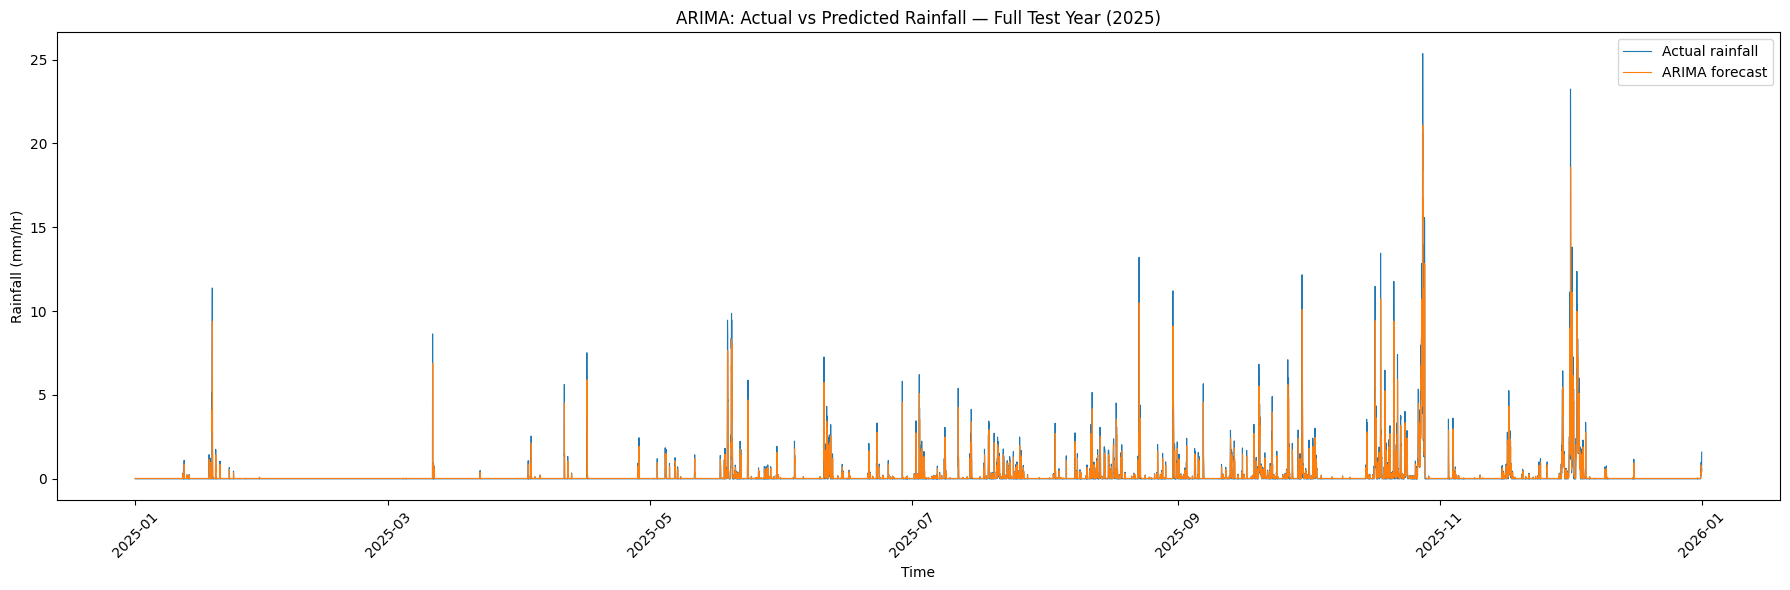

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.plot(
    test_df["timestamp"],
    test_rainfall,
    label="Actual rainfall",
    linewidth=0.8
)

plt.plot(
    test_df["timestamp"],
    arima_predictions,
    label="ARIMA forecast",
    linewidth=0.8
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("ARIMA: Actual vs Predicted Rainfall — Full Test Year (2025)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. LSTM

### Prediction matrics

In [ ]:
# Getting arima's metrics for 17472 observations

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Keep only the ARIMA predictions corresponding to the same
# 17,472 timestamps used by the neural-network models
arima_predictions_17472 = arima_predictions[LOOKBACK:]

# Calculate metrics
arima_mae_17472 = mean_absolute_error(
    y_test,
    arima_predictions_17472
)

arima_rmse_17472 = np.sqrt(
    mean_squared_error(
        y_test,
        arima_predictions_17472
    )
)

arima_r2_17472 = r2_score(
    y_test,
    arima_predictions_17472
)

In [ ]:

print("ARIMA — 2025 Test Performance")
print("--------------------------------")
print("Number of predictions:", len(arima_predictions_17472))
print(f"MAE  : {arima_mae_17472:.4f} mm/hr")
print(f"RMSE : {arima_rmse_17472:.4f} mm/hr")
print(f"R²   : {arima_r2_17472:.4f}")

ARIMA — 2025 Test Performance
--------------------------------
Number of predictions: 17472
MAE  : 0.1162 mm/hr
RMSE : 0.5157 mm/hr
R²   : 0.6661


### LSTM metrics

In [ ]:
lstm_pred_scaled = best_lstm_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

lstm_predictions = scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).flatten()


In [ ]:
print("Number of predictions:", len(lstm_predictions))
print("Prediction range:")
print("Min:", lstm_predictions.min())
print("Max:", lstm_predictions.max())

Number of predictions: 17472
Prediction range:
Min: 0.031827293
Max: 19.941965


hmm, I don't get numbers

### Visualizing prediction vs actual

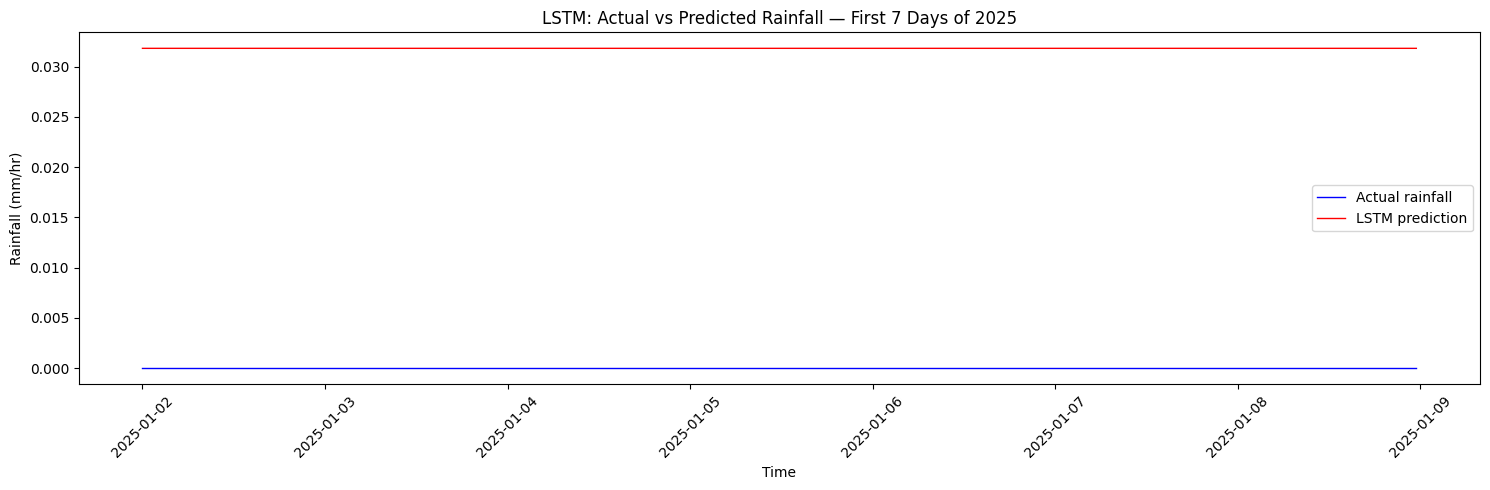

In [ ]:
n_points = 7 * 48

plt.figure(figsize=(15, 5))

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:LOOKBACK+n_points],
    y_test[:n_points],
    label="Actual rainfall",
    color="blue",
    linewidth=1
)

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:LOOKBACK+n_points],
    lstm_predictions[:n_points],
    label="LSTM prediction",
    color="red",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("LSTM: Actual vs Predicted Rainfall — First 7 Days of 2025")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

uhoh, 7 days don't tell you anything, let's test for whole year

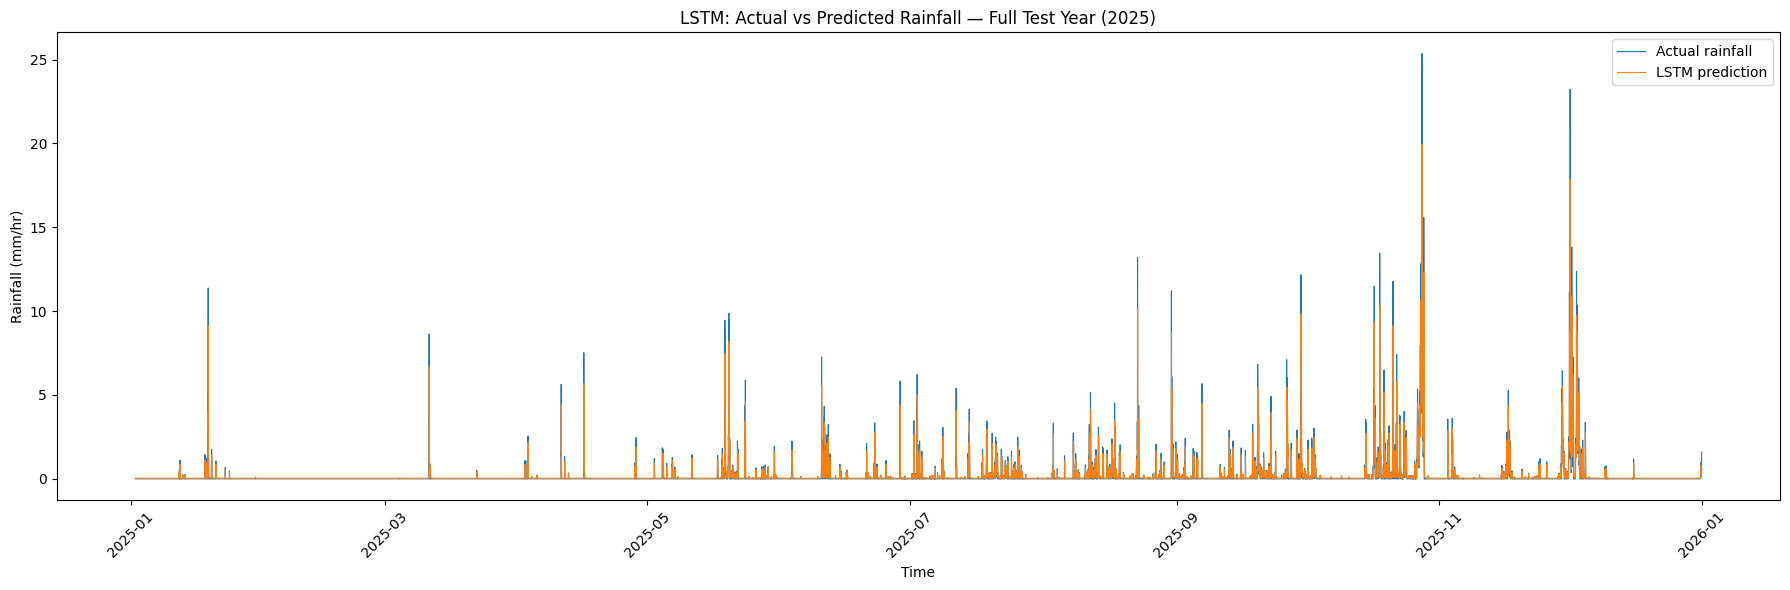

In [ ]:
plt.figure(figsize=(18, 6))

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    y_test,
    label="Actual rainfall",
    linewidth=0.8
)

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    lstm_predictions,
    label="LSTM prediction",
    linewidth=0.8
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("LSTM: Actual vs Predicted Rainfall — Full Test Year (2025)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This looks like arima, let's compare them

### Comparison with ARIMA's predictions

In [ ]:
# Align ARIMA predictions with the neural-network test predictions
arima_test_aligned = arima_predictions[LOOKBACK:]

comparison = pd.DataFrame({
    "actual": y_test,
    "ARIMA": arima_test_aligned,
    "LSTM": lstm_predictions
})

# Difference between the two models
prediction_difference = np.abs(
    comparison["ARIMA"] - comparison["LSTM"]
)

print("Number of predictions:", len(comparison))

print("\nARIMA vs LSTM prediction difference:")
print("Mean absolute difference :", prediction_difference.mean())
print("Maximum difference       :", prediction_difference.max())

print("\nPrediction correlation:")
print(
    comparison[["ARIMA", "LSTM"]].corr().iloc[0, 1]
)

print("\nAverage predictions:")
print("ARIMA:", comparison["ARIMA"].mean())
print("LSTM :", comparison["LSTM"].mean())

print("\nNumber of exactly equal predictions:",
      (comparison["ARIMA"] == comparison["LSTM"]).sum())

Number of predictions: 17472

ARIMA vs LSTM prediction difference:
Mean absolute difference : 0.01465934003320412
Maximum difference       : 2.0420641585301205

Prediction correlation:
0.9990313686675633

Average predictions:
ARIMA: 0.1678197384327637
LSTM : 0.17957257

Number of exactly equal predictions: 0


hmm, they are highly correlated but they do not have a single equal prediction...

Now let's calculate lstm metrics

### Matrics calculations

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate LSTM predictions for the 17,472 test sequences
lstm_pred_scaled = best_lstm_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

# Convert predictions back to mm/hr
lstm_predictions_17472 = scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).flatten()

# Calculate metrics
lstm_mae_17472 = mean_absolute_error(
    y_test,
    lstm_predictions_17472
)

lstm_rmse_17472 = np.sqrt(
    mean_squared_error(
        y_test,
        lstm_predictions_17472
    )
)

lstm_r2_17472 = r2_score(
    y_test,
    lstm_predictions_17472
)

In [ ]:
print("LSTM — 2025 Test Performance")
print("--------------------------------")
print("Number of predictions:", len(lstm_predictions_17472))
print(f"MAE  : {lstm_mae_17472:.4f} mm/hr")
print(f"RMSE : {lstm_rmse_17472:.4f} mm/hr")
print(f"R²   : {lstm_r2_17472:.4f}")

LSTM — 2025 Test Performance
--------------------------------
Number of predictions: 17472
MAE  : 0.1254 mm/hr
RMSE : 0.5124 mm/hr
R²   : 0.6704


## 3. GRU

### Generate predictions

In [ ]:
# Generate final gru predictions on the unseen 2025 test set

gru_pred_scaled = best_gru_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

gru_predictions = scaler.inverse_transform(
    gru_pred_scaled.reshape(-1, 1)
).flatten()

In [ ]:
print("Number of predictions:", len(gru_predictions))
print("Prediction range:")
print("Min:", gru_predictions.min())
print("Max:", gru_predictions.max())

Number of predictions: 17472
Prediction range:
Min: 0.011888709
Max: 20.92219


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Generate GRU predictions for the 17,472 test sequences
gru_pred_scaled = best_gru_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

# Convert predictions back to mm/hr
gru_predictions_17472 = scaler.inverse_transform(
    gru_pred_scaled.reshape(-1, 1)
).flatten()

# Calculate metrics
gru_mae_17472 = mean_absolute_error(
    y_test,
    gru_predictions_17472
)

gru_rmse_17472 = np.sqrt(
    mean_squared_error(
        y_test,
        gru_predictions_17472
    )
)

gru_r2_17472 = r2_score(
    y_test,
    gru_predictions_17472
)

In [ ]:
print("GRU — 2025 Test Performance")
print("--------------------------------")
print("Number of predictions:", len(gru_predictions_17472))
print(f"MAE  : {gru_mae_17472:.4f} mm/hr")
print(f"RMSE : {gru_rmse_17472:.4f} mm/hr")
print(f"R²   : {gru_r2_17472:.4f}")

GRU — 2025 Test Performance
--------------------------------
Number of predictions: 17472
MAE  : 0.1073 mm/hr
RMSE : 0.5139 mm/hr
R²   : 0.6685


### Visualize pred vs actual

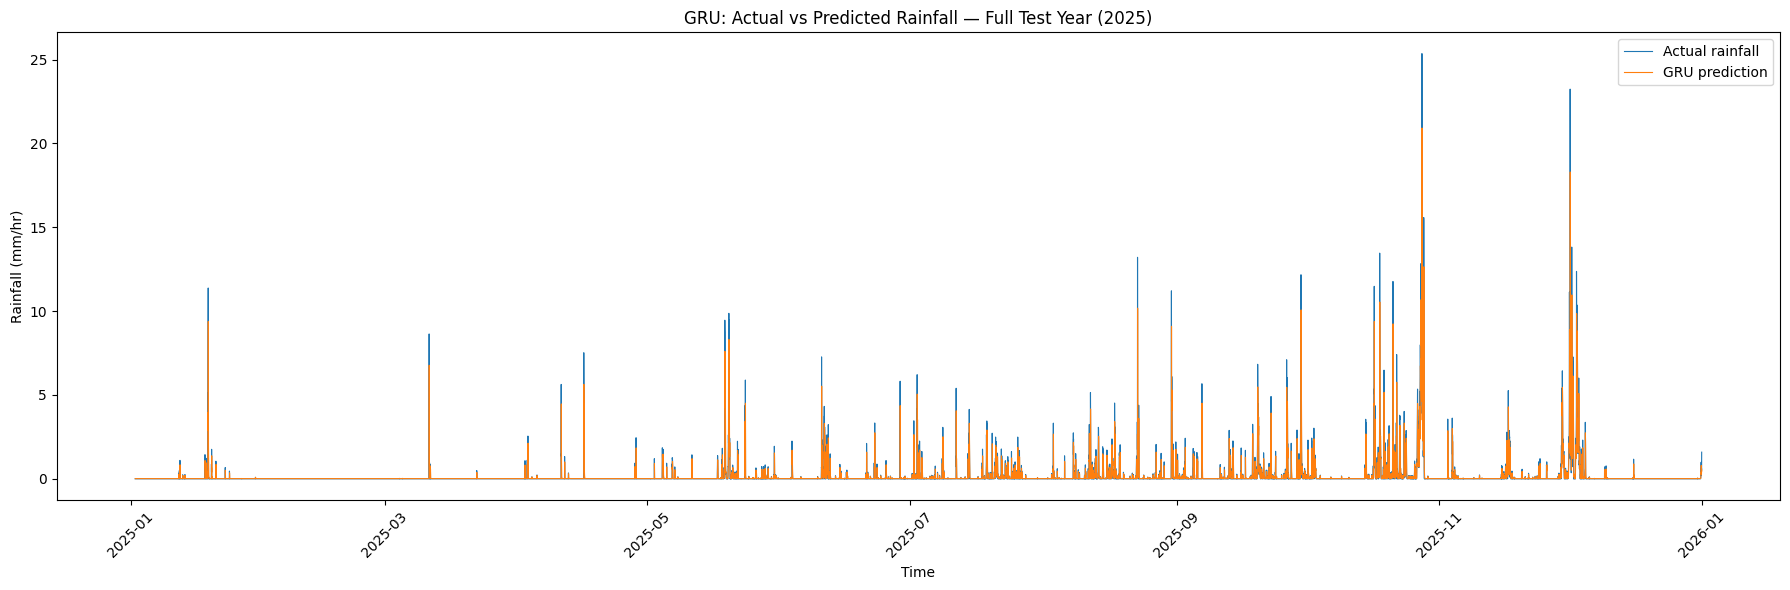

In [ ]:
plt.figure(figsize=(18, 6))

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    y_test,
    label="Actual rainfall",
    linewidth=0.8
)

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    gru_predictions_17472,
    label="GRU prediction",
    linewidth=0.8
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("GRU: Actual vs Predicted Rainfall — Full Test Year (2025)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 1D-CNN

### Make predictions
Make the prediction and print them

In [ ]:
# Importing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Generate CNN predictions for 17472 test sequences
cnn_pred_scaled = best_cnn_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

In [ ]:
# Convert predictions back to mm/hr
cnn_predictions_17472 = scaler.inverse_transform(
    cnn_pred_scaled.reshape(-1, 1)
).flatten()

In [ ]:
# Calculate metrics
cnn_mae_17472 = mean_absolute_error(
    y_test,
    cnn_predictions_17472
)

cnn_rmse_17472 = np.sqrt(
    mean_squared_error(
        y_test,
        cnn_predictions_17472
    )
)

cnn_r2_17472 = r2_score(
    y_test,
    cnn_predictions_17472
)

In [ ]:
# Printing
print("CNN — 2025 Test Performance")
print("--------------------------------")
print("Number of predictions:", len(cnn_predictions_17472))
print(f"MAE  : {cnn_mae_17472:.4f} mm/hr")
print(f"RMSE : {cnn_rmse_17472:.4f} mm/hr")
print(f"R²   : {cnn_r2_17472:.4f}")

CNN — 2025 Test Performance
--------------------------------
Number of predictions: 17472
MAE  : 0.2228 mm/hr
RMSE : 0.6724 mm/hr
R²   : 0.4326


### Visualize it for one year

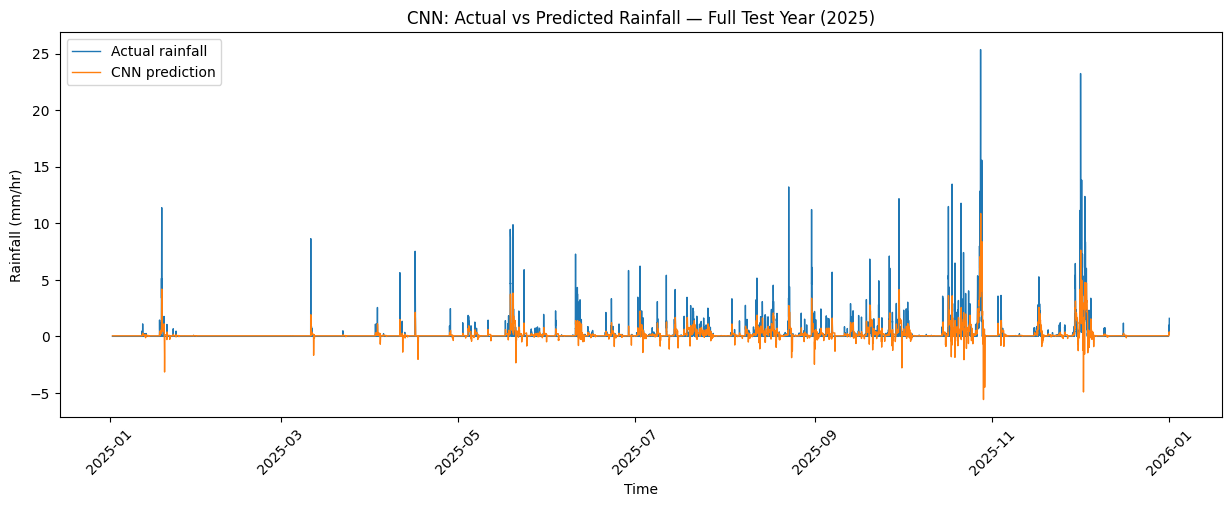

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    y_test,
    label="Actual rainfall",
    linewidth=1
)

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    cnn_predictions_17472,
    label="CNN prediction",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("CNN: Actual vs Predicted Rainfall — Full Test Year (2025)")
plt.legend()
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

## 5. CNN-LSTM

### Predictions
Let's predict the values

In [ ]:
# Importing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
# Generate CNN-LSTM predictions
cnn_lstm_pred_scaled = best_cnn_lstm_model.predict(
    X_test_lstm,
    verbose=0
).flatten()

In [ ]:
# Convert predictions back to mm/hr
cnn_lstm_predictions_17472 = scaler.inverse_transform(
    cnn_lstm_pred_scaled.reshape(-1, 1)
).flatten()

In [ ]:
# Calculate metrics
cnn_lstm_mae_17472 = mean_absolute_error(
    y_test,
    cnn_lstm_predictions_17472
)

cnn_lstm_rmse_17472 = np.sqrt(
    mean_squared_error(
        y_test,
        cnn_lstm_predictions_17472
    )
)

cnn_lstm_r2_17472 = r2_score(
    y_test,
    cnn_lstm_predictions_17472
)

In [ ]:
# Print values
print("CNN-LSTM — 2025 Test Performance")
print("-------------------------------------")
print("Number of predictions:", len(cnn_lstm_predictions_17472))
print(f"MAE  : {cnn_lstm_mae_17472:.4f} mm/hr")
print(f"RMSE : {cnn_lstm_rmse_17472:.4f} mm/hr")
print(f"R²   : {cnn_lstm_r2_17472:.4f}")

CNN-LSTM — 2025 Test Performance
-------------------------------------
Number of predictions: 17472
MAE  : 0.1161 mm/hr
RMSE : 0.5093 mm/hr
R²   : 0.6744


### Visualization
Let's visualize the predictions of cnn_lstm

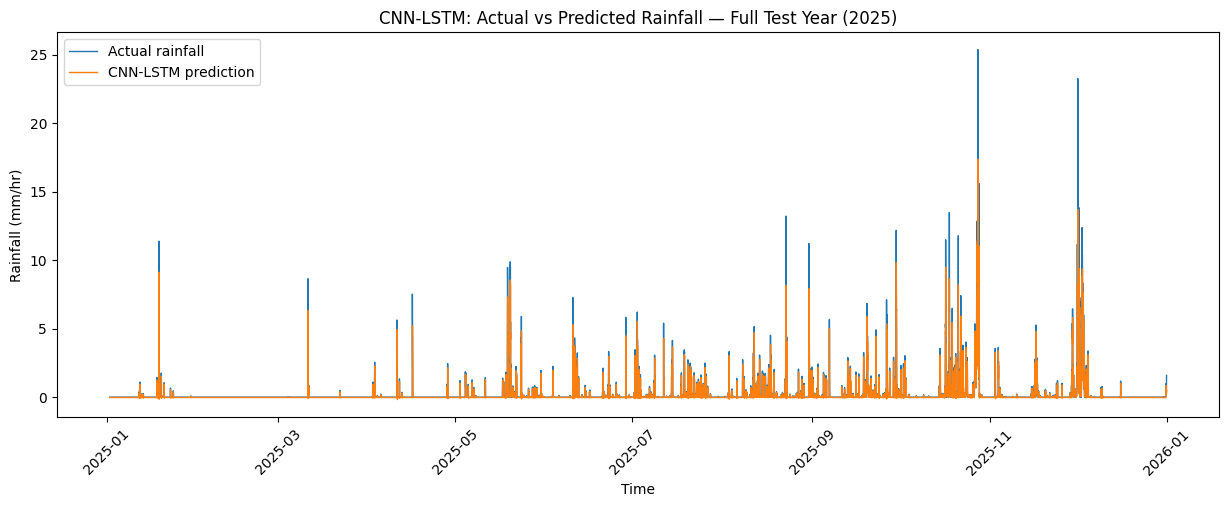

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    y_test,
    label="Actual rainfall",
    linewidth=1
)

plt.plot(
    test_df["timestamp"].iloc[LOOKBACK:],
    cnn_lstm_predictions_17472,
    label="CNN-LSTM prediction",
    linewidth=1
)

plt.xlabel("Time")
plt.ylabel("Rainfall (mm/hr)")
plt.title("CNN-LSTM: Actual vs Predicted Rainfall — Full Test Year (2025)")
plt.legend()
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()

# 7. Results
Now that all the training and evaluation is done, now we'll do the comparison and finally the best performance will be declared

### Tabular study
Firstly we'll make a table and then compare all the stats...

In [ ]:
# Importing
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Preparing a dataframe
results = pd.DataFrame({
    "Model": [
        "Persistence",
        "ARIMA",
        "LSTM",
        "GRU",
        "CNN",
        "CNN-LSTM"
    ],
    "MAE (mm/hr)": [
        persistence_mae,
        arima_mae_17472,
        lstm_mae_17472,
        gru_mae_17472,
        cnn_mae_17472,
        cnn_lstm_mae_17472
    ],
    "RMSE (mm/hr)": [
        persistence_rmse,
        arima_rmse_17472,
        lstm_rmse_17472,
        gru_rmse_17472,
        cnn_rmse_17472,
        cnn_lstm_rmse_17472
    ],
    "R²": [
        persistence_r2,
        arima_r2_17472,
        lstm_r2_17472,
        gru_r2_17472,
        cnn_r2_17472,
        cnn_lstm_r2_17472
    ]
})

In [ ]:
# Round off values for easier reading
results = results.round(4)

In [ ]:
print("FINAL MODEL COMPARISON - 2025 TEST SET")
display(results)

FINAL MODEL COMPARISON - 2025 TEST SET


,Model,MAE (mm/hr),RMSE (mm/hr),R²
0,Persistence,0.1004,0.5437,0.6289
1,ARIMA,0.1162,0.5157,0.6661
2,LSTM,0.1254,0.5124,0.6704
3,GRU,0.1073,0.5139,0.6685
4,CNN,0.2228,0.6724,0.4326
5,CNN-LSTM,0.1161,0.5093,0.6744


### Visualization
Numbers are hard to understand, let's draw a graph to understand better

In [ ]:
timestamps = test_df["timestamp"].iloc[LOOKBACK:]

# Giving variables
predictions = {
    "persistence": persistence_pred,
    "ARIMA": arima_predictions_17472,
    "LSTM": lstm_predictions_17472,
    "GRU": gru_predictions_17472,
    "1D-CNN": cnn_predictions_17472,
    "CNN-LSTM": cnn_lstm_predictions_17472
}

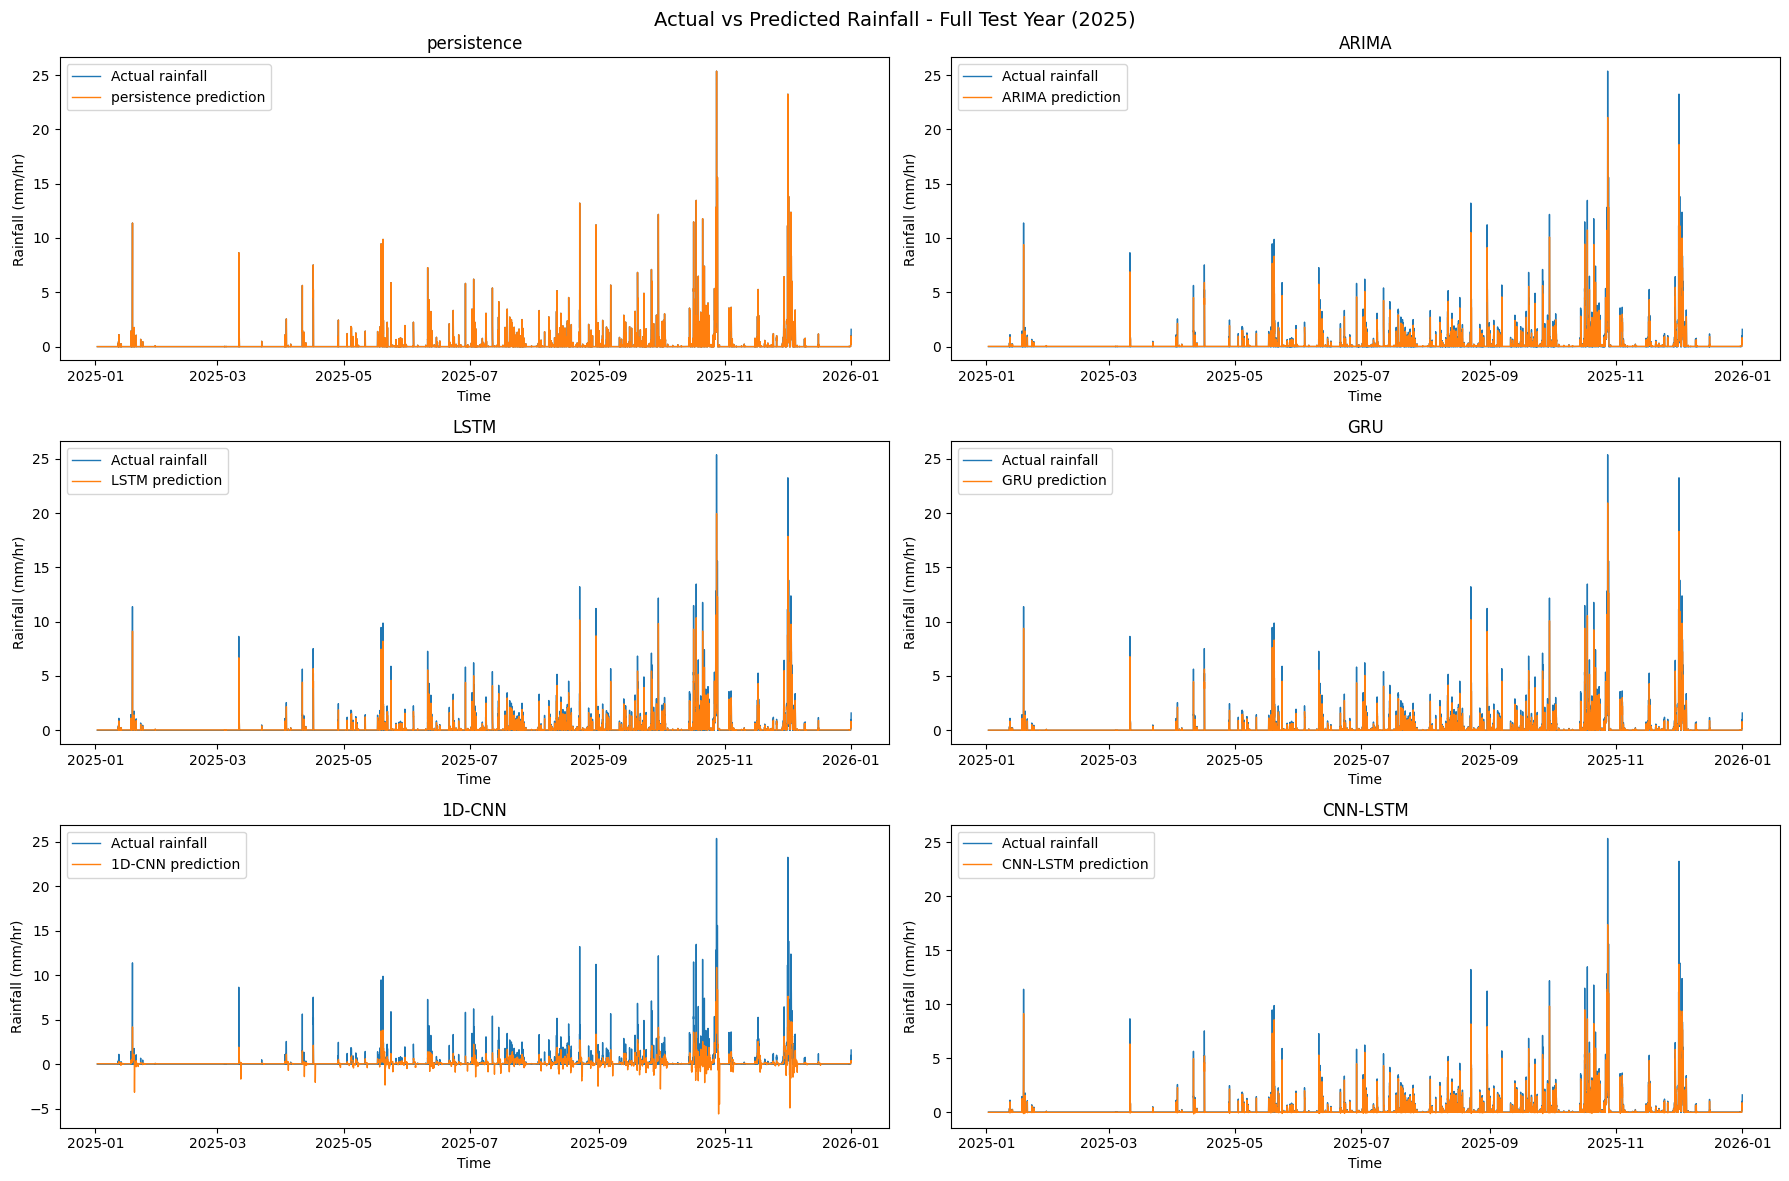

In [ ]:
fig, axes = plt.subplots(3,2,figsize=(18,12))

axes = axes.flatten()

for ax, (model_name, prediction) in zip(axes, predictions.items()):

  ax.plot(
      timestamps,
      y_test,
      label="Actual rainfall",
      linewidth=1
  )

  ax.plot(
      timestamps,
      prediction,
      label=f"{model_name} prediction",
      linewidth=1
  )

  ax.set_title(model_name)
  ax.set_xlabel("Time")
  ax.set_ylabel("Rainfall (mm/hr)")
  ax.legend()

plt.suptitle(
    "Actual vs Predicted Rainfall - Full Test Year (2025)",
    fontsize=14
)

plt.tight_layout()
plt.show()